In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
hist_df=pd.read_csv("data.csv")
hist_df.head()

,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
0,0,1,0,99.13,196.87,307.09,247.92,153.15,226.26
1,1,1,1,99.14,196.66,306.36,247.69,153.18,225.97
2,2,1,2,99.17,196.83,306.89,246.54,153.12,225.84
3,3,1,3,98.99,196.72,307.67,246.80,153.23,226.11
4,4,1,4,98.94,196.36,305.95,246.61,153.30,225.56


In [3]:
train_data=hist_df[hist_df["day"]<=30]
train_data

,Unnamed: 0,day,timestep,IND,AAA,BBB,CCC,DDD,ETF
0,0,1,0,99.13,196.87,307.09,247.92,153.15,226.26
1,1,1,1,99.14,196.66,306.36,247.69,153.18,225.97
2,2,1,2,99.17,196.83,306.89,246.54,153.12,225.84
3,3,1,3,98.99,196.72,307.67,246.80,153.23,226.11
4,4,1,4,98.94,196.36,305.95,246.61,153.30,225.56
...,...,...,...,...,...,...,...,...,...
11725,386,30,386,119.79,242.59,342.71,273.44,179.47,259.54
11726,387,30,387,119.80,242.75,341.49,273.85,179.56,259.40
11727,388,30,388,119.84,243.03,341.18,273.64,179.35,259.29
11728,389,30,389,119.96,243.66,341.53,274.09,179.10,259.59


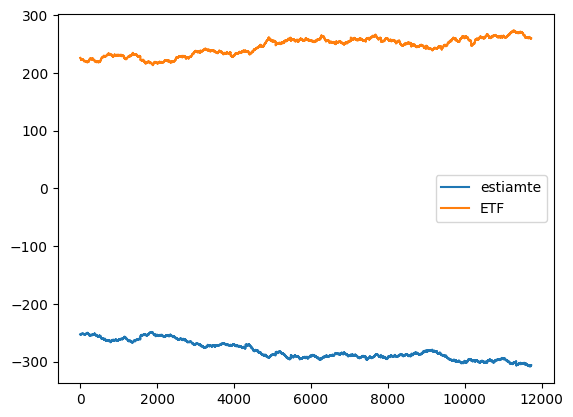

In [ ]:
intercept,coef=-15.801328357255073,2.37548408
sd=3.6381906636177406

y_fit=train_data["IND"]*coef+intercept
plt.plot(y_fit, label="estiamte")
plt.plot(train_data["ETF"],label="ETF")
#plt.plot(test_data["IND"],label=["IND"])

plt.legend()

In [ ]:
train_data.index

RangeIndex(start=0, stop=11730, step=1)

In [46]:
diff=train_data["ETF"]-y_fit
x=np.linspace(1,3,5)
y=np.linspace(0,2,5)
all=[]

for buy_in in x:
    for back in y:
        start_capital=1000000
        total=start_capital
        per=total/2
        tot_ETF=0
        tot_IND=0

        profit=[1]

        for i in train_data.index:
            if(i==0): continue

            if(diff[i]>=buy_in*sd and diff[i-1]<buy_in*sd):
                amount_etf=per//train_data["ETF"][i]
                amount_ind=per//train_data["IND"][i]

                tot_IND+=amount_ind
                tot_ETF-=amount_etf

                total+=amount_etf*train_data["ETF"][i]
                total-=amount_ind*train_data["IND"][i]

                #print(tot_ETF,i,total)

            if(diff[i]<=back*sd and diff[i-1]>back*sd and tot_ETF<0):
                total-=tot_ETF*train_data["ETF"][i]
                total+=tot_IND*train_data["IND"][i]
                tot_ETF=0
                tot_IND=0

                #print(tot_ETF,i,total)


            profit.append(total/start_capital)



        profit=pd.DataFrame(np.array(profit))
        #print(total)

        Rp=total/start_capital
        Rf=(train_data["IND"][11729]/train_data["IND"][0])
        #train_data["IND"]
        sigma=np.sqrt(profit[0].var())

        sharpe=(Rp-Rf)/sigma
        all.append((sharpe,total,buy_in,back))

all.sort(reverse=True)

for i in range(5):
    print(all[i])




C:\Users\ruimi\AppData\Local\Temp\ipykernel_12884\2714715718.py:52: RuntimeWarning: divide by zero encountered in scalar divide
  sharpe=(Rp-Rf)/sigma


(np.float64(-inf), 1000000, np.float64(3.0), np.float64(2.0))
(np.float64(-inf), 1000000, np.float64(3.0), np.float64(1.5))
(np.float64(-inf), 1000000, np.float64(3.0), np.float64(1.0))
(np.float64(-inf), 1000000, np.float64(3.0), np.float64(0.5))
(np.float64(-inf), 1000000, np.float64(3.0), np.float64(0.0))


In [ ]:
all.append((sharpe,total,buy_in,back))

all.sort(reverse=True)

for i in range(5):
    print(all[i])